# Pontificia Universidad Católica de Chile

# EPG4001 Aprendizaje Supervisado

# Material Complementario

# Clase2MIAApSup.pdf

**Dr. Jorge Luis Bazán**  
**jlbazan@uc.cl**

El presente es un documento complementario al material de la Clase 2 referente a regresión lineal, destinado a exponer la aplicación de los contenidos vistos en el software Python.

Al final del documento encontrará algunos ejercicios propuestos para practicar.


# 1. Librerías

Las librerías a utilizar para los procedimientos son las siguientes:


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import io
import shutil
import subprocess

from scipy import stats
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.diagnostic import het_breuschpagan, lilliefors, acorr_breusch_godfrey
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import jarque_bera, durbin_watson

def cargar_rdataset(nombre, paquete):
    try:
        return sm.datasets.get_rdataset(nombre, paquete).data
    except Exception as py_err:
        if shutil.which("Rscript") is None:
            raise RuntimeError(
                f"No se pudo cargar {paquete}::{nombre} con Python y Rscript no está disponible."
            ) from py_err

        r_code = f'''
        pkg <- "{paquete}"
        ds <- "{nombre}"
        if (pkg != "datasets" && !requireNamespace(pkg, quietly = TRUE)) {{
          install.packages(pkg, repos = "https://cloud.r-project.org")
        }}
        data(list = ds, package = pkg, envir = environment())
        write.csv(as.data.frame(get(ds)), row.names = FALSE)
        '''
        res = subprocess.run(["Rscript", "-e", r_code], capture_output=True, text=True)
        if res.returncode != 0:
            raise RuntimeError(
                f"No se pudo cargar {paquete}::{nombre} con Python ni con R.\n{res.stderr}"
            ) from py_err
        return pd.read_csv(io.StringIO(res.stdout))

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

# 2. Ejemplo 1.1: Data inversión/rendimiento

La información obtenida corresponde a una muestra de tamaño 12 sobre la relación existente entre la inversión realizada y el rendimiento obtenido, en cientos de miles de Euros para la explotación agrícola.

Cargando la data:


In [ ]:
data_inversion = pd.DataFrame({
    "inversion": [11, 14, 16, 15, 16, 18, 20, 21, 14, 20, 19, 11],
    "rendimiento": [2, 3, 5, 6, 5, 3, 7, 10, 6, 10, 5, 6],
})

data_inversion.head()

,inversion,rendimiento
0,11,2
1,14,3
2,16,5
3,15,6
4,16,5


## 2.1 Ajuste de modelo

Mediante la función `ols()` de `statsmodels` ajustamos la regresión lineal y almacenamos en un objeto `m1`; éste contendrá todos los resultados involucrados en el análisis.


In [ ]:
m1 = smf.ols("rendimiento ~ inversion", data=data_inversion).fit()

## 2.2 Resultados

Podemos obtener la tabla ANOVA con las sumas de cuadrados y el test F con `anova_lm()` y el valor de los coeficientes, su significancia y $R^{2}$ mediante `summary()`:


In [ ]:
# Tabla ANOVA
anova_lm(m1)

,df,sum_sq,mean_sq,F,PR(>F)
inversion,1.0,26.230019,26.230019,6.180983,0.032201
Residual,10.0,42.436647,4.243665,NaN,NaN


In [ ]:
# Resumen coeficientes, SE y significancia:
print(m1.summary())

                            OLS Regression Results                            
Dep. Variable:            rendimiento   R-squared:                       0.382
Model:                            OLS   Adj. R-squared:                  0.320
Method:                 Least Squares   F-statistic:                     6.181
Date:                Mon, 06 Jul 2026   Prob (F-statistic):             0.0322
Time:                        08:55:20   Log-Likelihood:                -24.606
No. Observations:                  12   AIC:                             53.21
Df Residuals:                      10   BIC:                             54.18
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.6823      3.015     -0.558      0.5

A partir de la tabla ANOVA vemos que el modelo sugiere explicar de manera significativa la variabilidad del rendimiento ($Y$), a partir del test $F$ ($F_{c}(1,10) \approx 6.181, p \approx 0.0322$) para un nivel de significancia del $\alpha=0.05$. Al contemplar este solo la variable inversión ($X$), lo anterior es equivalente a señalar que esta variable predice de manera significativa el rendimiento ($\beta_{1}\approx 0.452, p \approx 0.0322$).

En este caso al tratarse de una regresión simple notará que la significancia del coeficiente $\beta_{1}$ y el test $F$ es la misma; esto ocurre solo cuando el modelo presenta una variable explicativa.

Por otro lado el modelo explicaría cerca del 32% de la variabilidad del rendimiento ($R^{2}_{ajust} \approx 0.3202$).

Graficando valores predichos con bandas de confianza:


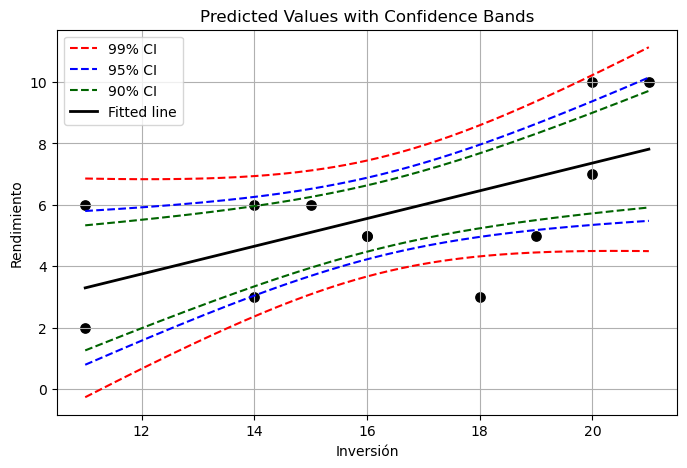

In [ ]:
newdata = pd.DataFrame({
    "inversion": np.linspace(
        data_inversion["inversion"].min(),
        data_inversion["inversion"].max(),
        200,
    )
})

pred90 = m1.get_prediction(newdata).summary_frame(alpha=0.10)
pred95 = m1.get_prediction(newdata).summary_frame(alpha=0.05)
pred99 = m1.get_prediction(newdata).summary_frame(alpha=0.01)

fig, ax = plt.subplots()
ax.scatter(data_inversion["inversion"], data_inversion["rendimiento"], color="black", s=45)
ax.set_xlabel("Inversión")
ax.set_ylabel("Rendimiento")
ax.set_title("Predicted Values with Confidence Bands")

ax.plot(newdata["inversion"], pred99["mean_ci_lower"], "--", color="red", label="99% CI")
ax.plot(newdata["inversion"], pred99["mean_ci_upper"], "--", color="red")
ax.plot(newdata["inversion"], pred95["mean_ci_lower"], "--", color="blue", label="95% CI")
ax.plot(newdata["inversion"], pred95["mean_ci_upper"], "--", color="blue")
ax.plot(newdata["inversion"], pred90["mean_ci_lower"], "--", color="darkgreen", label="90% CI")
ax.plot(newdata["inversion"], pred90["mean_ci_upper"], "--", color="darkgreen")
ax.plot(newdata["inversion"], pred95["mean"], color="black", linewidth=2, label="Fitted line")

ax.legend(loc="upper left")
plt.show()

# 3. Selección de modelos

Cargamos los datos de temperatura global de la base *globwarm* disponible en la librería *faraway* de R. Como esta base puede no estar disponible en algunos entornos de Python, se incluye una carga alternativa desde NASA GISTEMP y, si tampoco hay conexión, un respaldo local con la serie `nhtemp` de R:


In [ ]:
def cargar_globwarm():
    try:
        return cargar_rdataset("globwarm", "faraway")
    except Exception as err:
        print(f"No se pudo cargar globwarm desde faraway: {err}")

    try:
        nasa_url = "https://data.giss.nasa.gov/gistemp/tabledata_v4/NH.Ts+dSST.csv"
        nasa = pd.read_csv(nasa_url, skiprows=1, na_values=["***"])
        nasa.columns = [str(col).strip() for col in nasa.columns]

        globwarm_alt = nasa[["Year", "J-D"]].rename(
            columns={"Year": "year", "J-D": "nhtemp"}
        )
        globwarm_alt["year"] = pd.to_numeric(globwarm_alt["year"], errors="coerce")
        globwarm_alt["nhtemp"] = pd.to_numeric(globwarm_alt["nhtemp"], errors="coerce")
        globwarm_alt = globwarm_alt.dropna().copy()
        globwarm_alt["year"] = globwarm_alt["year"].astype(int)

        if globwarm_alt["nhtemp"].abs().median() > 10:
            globwarm_alt["nhtemp"] = globwarm_alt["nhtemp"] / 100

        return globwarm_alt
    except Exception as err:
        print(f"No se pudo cargar la alternativa NASA GISTEMP: {err}")

    nhtemp_valores = [
        49.9, 52.3, 49.4, 51.1, 49.4, 47.9, 49.8, 50.9, 49.3, 51.9,
        50.8, 49.6, 49.3, 50.6, 48.4, 50.7, 50.9, 50.6, 51.5, 52.8,
        51.8, 51.1, 49.8, 50.2, 50.4, 51.6, 51.8, 50.9, 48.8, 51.7,
        51.0, 50.6, 51.7, 51.5, 52.1, 51.3, 51.0, 54.0, 51.4, 52.7,
        53.1, 54.6, 52.0, 52.0, 50.9, 52.6, 50.2, 52.6, 51.6, 51.9,
        50.5, 50.9, 51.7, 51.4, 51.7, 50.8, 51.9, 51.8, 51.9, 53.0,
    ]
    return pd.DataFrame({
        "year": np.arange(1912, 1972),
        "nhtemp": nhtemp_valores,
    })


globwarm = cargar_globwarm()
globwarm.head()

,nhtemp,wusa,jasper,westgreen,chesapeake,tornetrask,urals,mongolia,tasman,year
0,NaN,-0.66,-0.03,0.03,-0.66,0.33,-1.49,0.83,-0.12,1000
1,NaN,-0.63,-0.07,0.09,-0.67,0.21,-1.44,0.96,-0.17,1001
2,NaN,-0.60,-0.11,0.18,-0.67,0.13,-1.39,0.99,-0.22,1002
3,NaN,-0.55,-0.14,0.30,-0.68,0.08,-1.34,0.95,-0.26,1003
4,NaN,-0.51,-0.15,0.41,-0.68,0.06,-1.30,0.87,-0.31,1004


Graficando la serie:


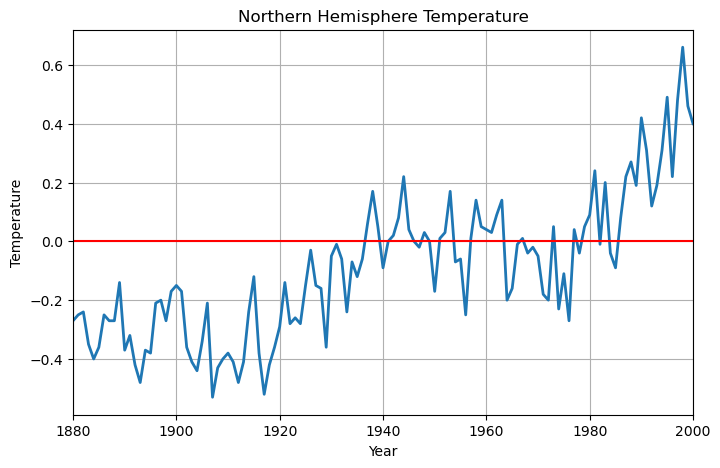

In [ ]:
# Mantenemos solo observaciones desde el año 1880
globwarm2 = globwarm.loc[globwarm["year"] >= 1880].copy()

fig, ax = plt.subplots()
ax.plot(globwarm2["year"], globwarm2["nhtemp"], linewidth=2)
ax.set_xlim(1880, 2000)
ax.set_xlabel("Year")
ax.set_ylabel("Temperature")
ax.set_title("Northern Hemisphere Temperature")
ax.axhline(0, color="red")
plt.show()

## 3.1 Ajuste de modelos

A continuación ajustamos los diferentes modelos que consideran polinomios de distintos grados:

$$M_{1}: \quad y=\beta_{0}+\beta_1t + \varepsilon_t$$


In [ ]:
mod_lin = smf.ols("nhtemp ~ year", data=globwarm2).fit()

$$M_{2}: \quad y=\beta_{0}+\beta_1t +\beta_{2}t^{2} +\varepsilon_t$$


In [ ]:
mod_quad = smf.ols("nhtemp ~ year + I(year ** 2)", data=globwarm2).fit()

$$M_{3}: \quad y=\beta_{0}+\beta_1t +\beta_{2}t^{2} + \beta_{3}t^{3} + \varepsilon_t$$


In [ ]:
mod_cubic = smf.ols("nhtemp ~ year + I(year ** 2) + I(year ** 3)", data=globwarm2).fit()

Resúmenes del ajuste de los modelos:


In [ ]:
print(mod_lin.summary())
print(mod_quad.summary())
print(mod_cubic.summary())

                            OLS Regression Results                            
Dep. Variable:                 nhtemp   R-squared:                       0.621
Model:                            OLS   Adj. R-squared:                  0.618
Method:                 Least Squares   F-statistic:                     195.0
Date:                Mon, 06 Jul 2026   Prob (F-statistic):           7.81e-27
Time:                        08:55:23   Log-Likelihood:                 59.970
No. Observations:                 121   AIC:                            -115.9
Df Residuals:                     119   BIC:                            -110.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -10.5738      0.751    -14.086      0.0

Comparando podemos ver que los modelos $M_2$ y $M_3$ tienen mayor $R^{2}$; para este último ninguna de las componentes muestra ser significativa ($p>0.05$), mientras que para el segundo todas resultan serlo ($p<0.05$), aunque el coeficiente que acompaña la componente cuadrática es casi 0 ($\beta_2\approx 0.0000336, p\approx 0.006$).

Comparando los modelos en términos de predicción gráficamente:


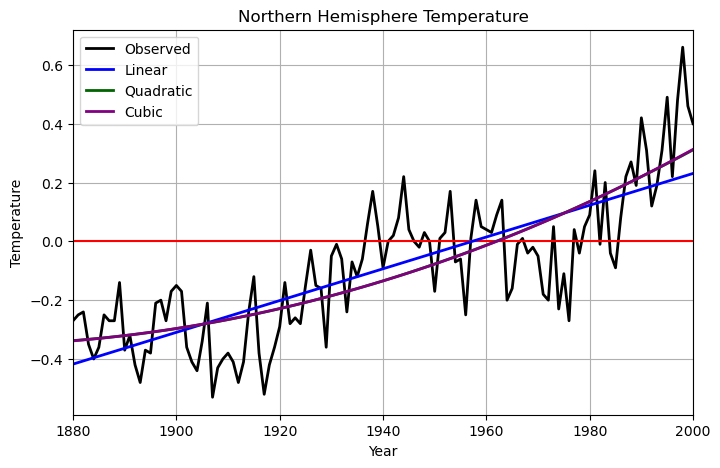

In [ ]:
fig, ax = plt.subplots()
ax.plot(globwarm2["year"], globwarm2["nhtemp"], color="black", linewidth=2, label="Observed")
ax.set_xlim(1880, 2000)
ax.set_xlabel("Year")
ax.set_ylabel("Temperature")
ax.set_title("Northern Hemisphere Temperature")
ax.axhline(0, color="red")
ax.plot(globwarm2["year"], mod_lin.predict(globwarm2), color="blue", linewidth=2, label="Linear")
ax.plot(globwarm2["year"], mod_quad.predict(globwarm2), color="darkgreen", linewidth=2, label="Quadratic")
ax.plot(globwarm2["year"], mod_cubic.predict(globwarm2), color="purple", linewidth=2, label="Cubic")
ax.legend(loc="upper left")
plt.show()

## 3.2 Comparación de modelos

Podemos comparar también los modelos en términos de sumas de cuadrados con la función `anova_lm()`:


In [ ]:
anova_lm(mod_lin, mod_quad, mod_cubic)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,119.0,2.629184,0.0,NaN,NaN,NaN
1,118.0,2.466354,1.0,0.162830,7.795534,0.006112
2,118.0,2.464743,-0.0,0.001611,-inf,NaN


Vemos que hay diferencia significativa entre el primer y segundo modelo ($F\approx 7.78,p\approx 0.006$), mas no con el tercero ($F\approx 0.94,p\approx 0.33$). Comparando ahora en términos de AIC, BIC y $R^{2}$:


In [ ]:
pd.DataFrame({
    "Model": ["M1", "M2", "M3"],
    "AIC": [mod_lin.aic, mod_quad.aic, mod_cubic.aic],
    "BIC": [mod_lin.bic, mod_quad.bic, mod_cubic.bic],
    "Adj_R2": [mod_lin.rsquared_adj, mod_quad.rsquared_adj, mod_cubic.rsquared_adj],
})

,Model,AIC,BIC,Adj_R2
0,M1,-115.940029,-110.348448,0.617833
1,M2,-121.675891,-113.288520,0.638463
2,M3,-121.754945,-113.367573,0.638699


Siguiendo el criterio AIC y BIC efectivamente el segundo modelo es el que mejor ajuste presenta al tener los valores más bajos; vemos también que el cambio en términos de explicabilidad ($R^{2}$) es importante entre el segundo y el primer modelo, pero ya no entre el segundo y el tercero. Todos los criterios apuntan a que el segundo modelo es el que presenta mejor ajuste.


# 4. Verificación supuestos

Para esto utilizaremos la base de datos *PimaIndiansDiabetes* (librería *mlbench* en R), que consiste en información referente a mujeres de ascendencia India que viven en EE.UU. (revisar material complementario 1).

Cargando los datos:


In [ ]:
def cargar_pima():
    try:
        return cargar_rdataset("PimaIndiansDiabetes", "mlbench")
    except Exception as err:
        print(f"No se pudo cargar PimaIndiansDiabetes desde mlbench con Python/R: {err}")

    columnas = [
        "pregnant", "glucose", "pressure", "triceps", "insulin",
        "mass", "pedigree", "age", "diabetes",
    ]
    url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
    datos = pd.read_csv(url, names=columnas)
    datos["diabetes"] = datos["diabetes"].map({0: "neg", 1: "pos"})
    return datos


datos_pima = cargar_pima()
datos_pima.head()

,pregnant,glucose,pressure,triceps,insulin,mass,pedigree,age,diabetes
0,6,148,72,35,0,33.6,0.627,50,pos
1,1,85,66,29,0,26.6,0.351,31,neg
2,8,183,64,0,0,23.3,0.672,32,pos
3,1,89,66,23,94,28.1,0.167,21,neg
4,0,137,40,35,168,43.1,2.288,33,pos


Realizaremos un análisis de regresión para explorar si la edad ($x_{1}$), IMC ($x_{2}$) y el grosor del pliegue cutáneo del tríceps ($x_{3}$) explican o no la concentración de glucosa en plasma ($y$). Así, el modelo es

$$y=\beta_{0} +\beta_{1}x_{1} + \beta_{2}x_{2} + \beta_{3}x_{3} + \varepsilon, \quad \text{con} \quad \varepsilon \sim N(0,\sigma^{2})$$

Ajustando el modelo y explorando sus resultados:


In [ ]:
m4 = smf.ols("glucose ~ age + mass + triceps", data=datos_pima).fit()
print(m4.summary())

                            OLS Regression Results                            
Dep. Variable:                glucose   R-squared:                       0.114
Model:                            OLS   Adj. R-squared:                  0.111
Method:                 Least Squares   F-statistic:                     32.85
Date:                Mon, 06 Jul 2026   Prob (F-statistic):           5.62e-20
Time:                        08:55:23   Log-Likelihood:                -3703.7
No. Observations:                 768   AIC:                             7415.
Df Residuals:                     764   BIC:                             7434.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     70.2902      5.406     13.003      0.0

En principio podemos ver que la edad y el IMC resultan significativas para explicar el nivel de glucosa; chequeemos los supuestos del modelo para así verificar si esta inferencia es confiable o no:

## 4.1 VIF

Chequeando si hay o no problemas de multicolinealidad podemos obtener el VIF para cada variable mediante `variance_inflation_factor()`:


In [ ]:
X_vif = sm.add_constant(datos_pima[["age", "mass", "triceps"]])

pd.DataFrame({
    "variable": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})

,variable,VIF
0,const,24.687688
1,age,1.021182
2,mass,1.191552
3,triceps,1.205647


Dado que todos los valores son inferiores a 10 no habría problemas de colinealidad.

## 4.2 Chequeando homocedasticidad

Gráficamente se puede chequear con un gráfico entre los residuos y los valores ajustados:


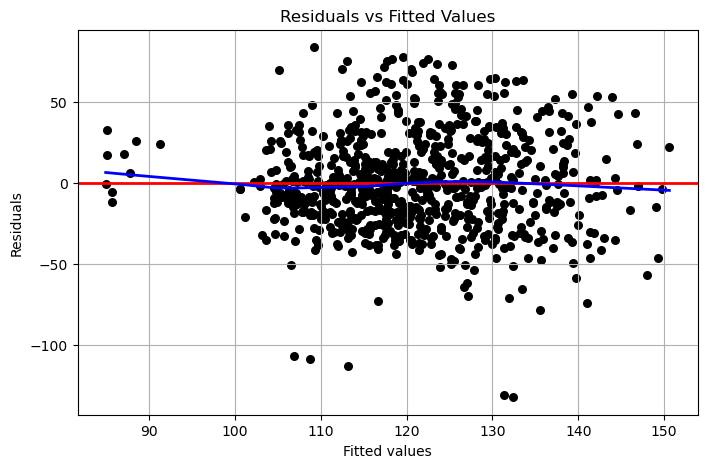

In [ ]:
fig, ax = plt.subplots()
ax.scatter(m4.fittedvalues, m4.resid, color="black", s=30)
ax.set_xlabel("Fitted values")
ax.set_ylabel("Residuals")
ax.set_title("Residuals vs Fitted Values")
ax.axhline(0, color="red", linewidth=2)
lowess = sm.nonparametric.lowess(m4.resid, m4.fittedvalues)
ax.plot(lowess[:, 0], lowess[:, 1], color="blue", linewidth=2)
plt.show()

En general gráficamente no se observa un comportamiento sistemático de los residuos para la mayor cantidad de puntos, sino más bien una nube aleatoria de puntos, lo cual es señal de que hay homocedasticidad. Sin embargo, para valores ajustados menores (cerca de $\hat{y}_{i} \approx 90$) se puede observar un pequeño grupo de puntos que presentan menor dispersión.

Podemos seguir explorando este supuesto con el test Breusch-Pagan mediante `het_breuschpagan()`:


In [ ]:
bp_stat, bp_pvalue, f_stat, f_pvalue = het_breuschpagan(m4.resid, m4.model.exog)

pd.DataFrame({
    "estadístico": ["LM", "F"],
    "valor": [bp_stat, f_stat],
    "p_value": [bp_pvalue, f_pvalue],
})

,estadístico,valor,p_value
0,LM,14.873094,0.001928
1,F,5.029274,0.001859


Podemos ver según este test que se rechaza la hipótesis de homocedasticidad, por lo que este supuesto no se estaría cumpliendo. En estos casos lo que falla es la estimación de los errores estándar de los estimadores $\operatorname{SE}[\hat{\beta}_{j}]$ y por ende la inferencia asociada a ellos con los resultados obtenidos puede no ser cierta. En estos casos, tanto de homocedasticidad como de presencia de autocorrelación en los errores se pueden recalcular correctamente los errores estándar mediante las matrices de White o Newey-West.

## 4.3 Autocorrelación

La autocorrelación de orden 1 (lag=1) la podemos chequear mediante el estadístico de Durbin-Watson. Además, se agrega una prueba Breusch-Godfrey de orden 1 para obtener un valor-p:


In [ ]:
dw = durbin_watson(m4.resid)
bg = acorr_breusch_godfrey(m4, nlags=1)

pd.DataFrame({
    "prueba": ["Durbin-Watson", "Breusch-Godfrey lag 1"],
    "estadístico": [dw, bg[0]],
    "p_value": [np.nan, bg[1]],
})

,prueba,estadístico,p_value
0,Durbin-Watson,1.836653,NaN
1,Breusch-Godfrey lag 1,5.128485,0.023536


Este test entonces también rechaza la hipótesis nula de no autocorrelación, con un 95% de confianza.

## 4.4 Normalidad de los errores

Para chequear la normalidad de los errores revisaremos varios tests:

### 4.4.1 Shapiro-Wilk


In [ ]:
res = m4.resid
stats.shapiro(res)

ShapiroResult(statistic=0.9790088236508484, pvalue=4.763878863129959e-09)

### 4.4.2 Kolmogorov-Smirnov


In [ ]:
stats.kstest(stats.zscore(res), "norm")

KstestResult(statistic=0.06623247464408333, pvalue=0.002256984305220333, statistic_location=0.10179010159627608, statistic_sign=1)

### 4.4.3 Jarque-Bera


In [ ]:
jb_stat, jb_pvalue, skew, kurtosis = jarque_bera(res)

pd.DataFrame({
    "estadístico": ["Jarque-Bera", "Skewness", "Kurtosis"],
    "valor": [jb_stat, skew, kurtosis],
    "p_value": [jb_pvalue, np.nan, np.nan],
})

,estadístico,valor,p_value
0,Jarque-Bera,39.029539,3.348446e-09
1,Skewness,-0.008773,NaN
2,Kurtosis,4.104249,NaN


### 4.4.4 Lilliefors


In [ ]:
lillie_stat, lillie_pvalue = lilliefors(res)

pd.DataFrame({
    "estadístico": ["Lilliefors"],
    "valor": [lillie_stat],
    "p_value": [lillie_pvalue],
})

,estadístico,valor,p_value
0,Lilliefors,0.066259,0.001


Para todos los tests se rechaza $H_{0}$ que supone normalidad de los errores, con un 95% de confianza; así, no podemos asumir que este supuesto de normalidad se esté cumpliendo.

Podemos explorar esto gráficamente mediante un gráfico QQ que compara los cuantiles teóricos de la distribución normal versus los observados:

### 4.4.5 QQnorm plot


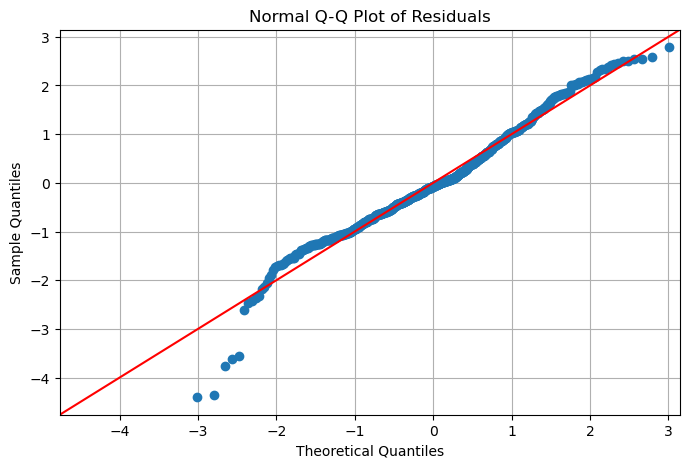

In [ ]:
fig = sm.qqplot(m4.resid, line="45", fit=True)
plt.title("Normal Q-Q Plot of Residuals")
plt.grid(True)
plt.show()

Vemos efectivamente que para los cuantiles extremos hay un alejamiento de la normalidad, siendo esto más fuerte para los residuos más negativos.


# 5. Ejercicio propuesto

En una universidad se desea explorar si las variables género, años en la institución y tiempo desde el cual se obtuvo el último grado explican o no el salario de los docentes que trabajan en ella, para esto se dispone de la siguiente muestra:


In [ ]:
datos_ej = pd.DataFrame({
    "Salario": [
        36.35, 35.35, 28.2, 26.775, 33.696, 28.516, 24.9, 31.909,
        31.85, 32.85, 27.025, 24.75, 28.2, 23.712, 25.748, 29.342,
        31.114, 24.742, 22.906, 24.45, 19.175, 20.525, 27.959,
        38.045, 24.832, 25.4, 24.8, 25.5, 26.182, 23.725, 21.6,
        23.3, 23.713, 20.69, 22.45, 20.85, 18.304, 17.095, 16.7,
        17.6, 18.075, 18, 20.999, 17.25, 16.5, 16.094, 16.15,
        15.35, 16.244, 16.686, 15, 20.3
    ],
    "Genero": [
        0,0,0,1,0,0,1,0,
        0,0,0,0,0,0,0,0,
        0,0,0,0,0,0,0,1,
        0,0,0,1,0,0,1,0,
        0,1,1,0,1,0,0,0,
        0,0,0,1,0,0,1,1,
        0,1,1,1
    ],
    "Años": [
        25,13,10,7,19,16,0,16,
        13,13,12,15,9,9,9,7,
        13,11,10,6,16,8,7,8,
        9,5,11,5,3,3,10,11,
        9,4,6,1,8,4,4,4,
        3,3,0,3,2,2,2,2,
        1,1,1,0
    ],
    "Tiempo": [
        35,22,23,27,30,21,32,18,
        30,31,22,19,17,27,24,15,
        20,14,15,21,23,31,13,24,
        12,18,14,16,7,17,15,31,
        14,33,29,9,14,4,5,4,
        4,11,7,3,3,1,6,2,
        1,1,1,2
    ]
})

datos_ej.head()

,Salario,Genero,Años,Tiempo
0,36.350,0,25,35
1,35.350,0,13,22
2,28.200,0,10,23
3,26.775,1,7,27
4,33.696,0,19,30


Realice un completo análisis de regresión que responda las inquietudes del estudio, considere:

1. Plantear variables, modelo teórico y sus supuestos.
2. Ajustar el modelo a los datos.
3. Chequee si se verifican o no los supuestos relacionados.
4. Responda a las inquietudes de la investigación en términos de las variables, ¿Cuál es la interpretación de los coeficientes estimados?
5. Muestre gráficamente para la variable años en la institución las predicciones realizadas por el modelo.
6. Explore gráficamente los supuestos de homocedasticidad y normalidad de los errores.

Una forma de iniciar el análisis en Python es la siguiente:


In [ ]:
modelo_ej = smf.ols('Salario ~ Genero + Q("Años") + Tiempo', data=datos_ej).fit()
print(modelo_ej.summary())

                            OLS Regression Results                            
Dep. Variable:                Salario   R-squared:                       0.581
Model:                            OLS   Adj. R-squared:                  0.555
Method:                 Least Squares   F-statistic:                     22.17
Date:                Mon, 06 Jul 2026   Prob (F-statistic):           3.76e-09
Time:                        08:55:24   Log-Likelihood:                -143.12
No. Observations:                  52   AIC:                             294.2
Df Residuals:                      48   BIC:                             302.1
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     16.8673      1.204     14.012      0.0

In [ ]:
# Tabla ANOVA del modelo propuesto
anova_lm(modelo_ej)

,df,sum_sq,mean_sq,F,PR(>F)
Genero,1.0,114.106220,114.106220,7.316782,9.425931e-03
"Q(""Años"")",1.0,762.930168,762.930168,48.921032,7.501025e-09
Tiempo,1.0,160.126928,160.126928,10.267748,2.407176e-03
Residual,48.0,748.566542,15.595136,NaN,NaN


In [ ]:
# VIF para las variables explicativas
X_ej = sm.add_constant(datos_ej[["Genero", "Años", "Tiempo"]])

pd.DataFrame({
    "variable": X_ej.columns,
    "VIF": [variance_inflation_factor(X_ej.values, i) for i in range(X_ej.shape[1])]
})

,variable,VIF
0,const,4.831888
1,Genero,1.225558
2,Años,2.054184
3,Tiempo,1.772305


In [ ]:
# Breusch-Pagan para homocedasticidad
bp_ej = het_breuschpagan(modelo_ej.resid, modelo_ej.model.exog)

pd.DataFrame({
    "estadístico": ["LM", "F"],
    "valor": [bp_ej[0], bp_ej[2]],
    "p_value": [bp_ej[1], bp_ej[3]],
})

,estadístico,valor,p_value
0,LM,3.525440,0.317478
1,F,1.163642,0.333372


In [ ]:
# Pruebas de normalidad
res_ej = modelo_ej.resid

pd.DataFrame({
    "prueba": ["Shapiro-Wilk", "Kolmogorov-Smirnov", "Jarque-Bera", "Lilliefors"],
    "estadístico": [
        stats.shapiro(res_ej).statistic,
        stats.kstest(stats.zscore(res_ej), "norm").statistic,
        jarque_bera(res_ej)[0],
        lilliefors(res_ej)[0],
    ],
    "p_value": [
        stats.shapiro(res_ej).pvalue,
        stats.kstest(stats.zscore(res_ej), "norm").pvalue,
        jarque_bera(res_ej)[1],
        lilliefors(res_ej)[1],
    ],
})

,prueba,estadístico,p_value
0,Shapiro-Wilk,0.968998,0.191557
1,Kolmogorov-Smirnov,0.095973,0.688390
2,Jarque-Bera,7.760334,0.020647
3,Lilliefors,0.095975,0.279283


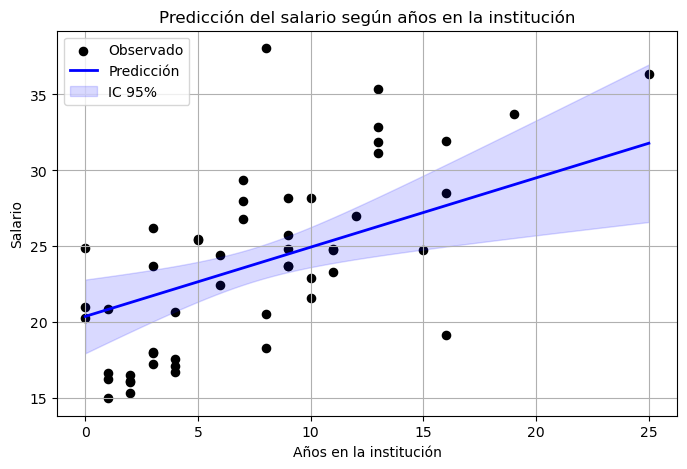

In [ ]:
# Predicciones para la variable años en la institución,
# manteniendo Género y Tiempo en sus valores promedio.
pred_anios = pd.DataFrame({
    "Genero": datos_ej["Genero"].mean(),
    "Años": np.linspace(datos_ej["Años"].min(), datos_ej["Años"].max(), 200),
    "Tiempo": datos_ej["Tiempo"].mean(),
})

pred_ej = modelo_ej.get_prediction(pred_anios).summary_frame(alpha=0.05)

fig, ax = plt.subplots()
ax.scatter(datos_ej["Años"], datos_ej["Salario"], color="black", s=35, label="Observado")
ax.plot(pred_anios["Años"], pred_ej["mean"], color="blue", linewidth=2, label="Predicción")
ax.fill_between(
    pred_anios["Años"],
    pred_ej["mean_ci_lower"],
    pred_ej["mean_ci_upper"],
    color="blue",
    alpha=0.15,
    label="IC 95%",
)
ax.set_xlabel("Años en la institución")
ax.set_ylabel("Salario")
ax.set_title("Predicción del salario según años en la institución")
ax.legend()
plt.show()

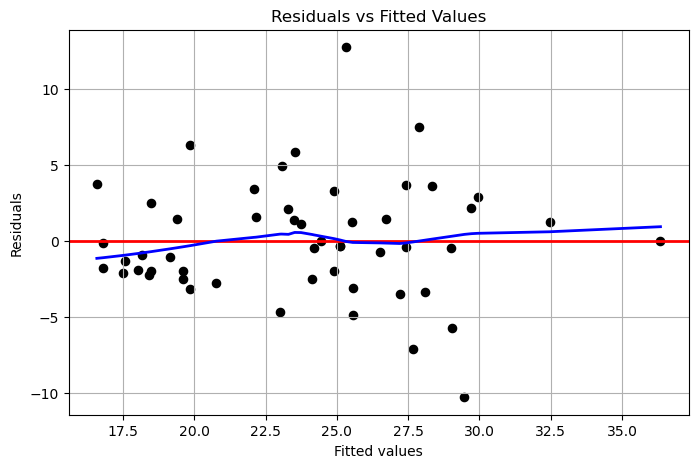

In [ ]:
# Homocedasticidad: residuos versus valores ajustados
fig, ax = plt.subplots()
ax.scatter(modelo_ej.fittedvalues, modelo_ej.resid, color="black", s=35)
ax.axhline(0, color="red", linewidth=2)
lowess_ej = sm.nonparametric.lowess(modelo_ej.resid, modelo_ej.fittedvalues)
ax.plot(lowess_ej[:, 0], lowess_ej[:, 1], color="blue", linewidth=2)
ax.set_xlabel("Fitted values")
ax.set_ylabel("Residuals")
ax.set_title("Residuals vs Fitted Values")
plt.show()

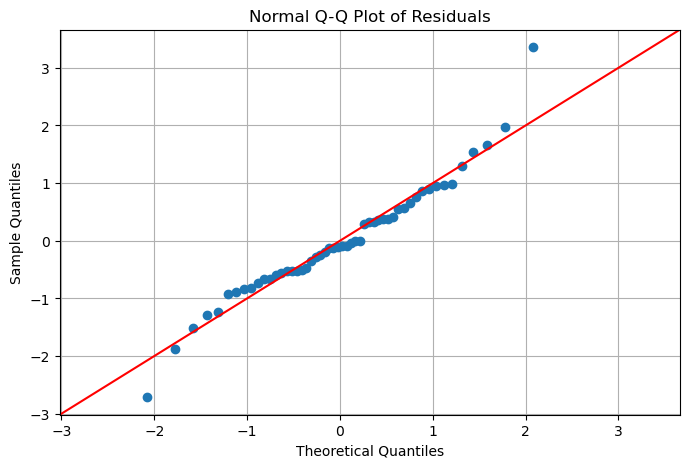

In [ ]:
# Normalidad: gráfico Q-Q
fig = sm.qqplot(modelo_ej.resid, line="45", fit=True)
plt.title("Normal Q-Q Plot of Residuals")
plt.grid(True)
plt.show()

# 6. Bibliografía

- Julian J. Faraway (2016). *Extending the Linear Model with R: Generalized Linear, Mixed Effects and Nonparametric Regression Models*, Boca Raton: Chapman Hall/CRC.
- Krzanowski, W. (1998). *An Introduction to Statistical Modelling*. Arnold, New York.
